# undersøg de forskellige køller som forskellige punkter, hvor punkterne på kurven er forskellige z0 værdier

In [1]:
2+2

4

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from Tracer.windfield import WindField
from Tracer.tracer import solver, initial_velocity, fetch_wind_data, initial_spin_rate

## Investigating the difference between log and uniform wind

In [4]:
# Contents

#1. Simulator
#   - setup                        | playfield-, basis shot-, and wind parameters)
#   - parameter library            | designing which values for each param should be tested)
#   - run_simulation()             | Runs the trajectory model with given inputs
#   - percent_distance_error()     | Calculates the distance betweem landing points, normalized)
#   - varying_parameter()          | Takes a parameter from the library and plots the resulting trajectories and errors
#   - varying_two_parameters()     | Takes two parameters and makes a heatplot of the error

### Simulator

In [3]:
# play field parameters - dont touch unless necessary
P0=np.array([0, 0, 0])
nx = 500        # length of play field
ny = 200        # width of play field
nz = 100        # height of play field
dt = 0.01       # time step

# Basis shot parameters - if not otherwise specified, these are used
shot_speed = 76.44384   # intital velocity
shot_angle = 10.4       # initial angle for trajectory	
shot_spin = 2545        # initial spin

spin_axis = 1.25

# Basis wind parameters - if not otherwise specified, these are used
U_ref = 6      # reference wind speed at 10 meters above ground (6 m/s is approx. danish average)
z0 = 0.03       # surface roughness
direction = 0   # wind direction (0 is tailwind, 180 is headwind)

In [11]:

pga_data = [
    ["Driver", 115, -0.9, 171, 1.49, 10.4, 2545, 32, 39, 258],
    ["3-wood", 110, -2.3, 162, 1.47, 9.3, 3663, 29, 44, 228],
    ["5-wood", 106, -2.5, 156, 1.47, 9.7, 4322, 30, 48, 216],
    ["Hybrid", 102, -2.4, 149, 1.47, 10.2, 4587, 28, 49, 211],
    ["3 Iron", 100, -2.5, 145, 1.46, 10.3, 4404, 27, 48, 199],
    ["4 Iron", 98, -2.9, 140, 1.44, 10.8, 4782, 28, 49, 192],
    ["5 Iron", 96, -3.4, 135, 1.41, 11.9, 5280, 30, 50, 182],
    ["6 Iron", 94, -3.7, 130, 1.39, 14.0, 6204, 29, 50, 172],
    ["7 Iron", 92, -3.9, 123, 1.34, 16.1, 7124, 31, 51, 161],
    ["8 Iron", 89, -4.2, 118, 1.33, 17.8, 8078, 30, 51, 150],
    ["9 Iron", 87, -4.3, 112, 1.29, 20.0, 8793, 29, 52, 139],
    ["PW", 84, -4.7, 104, 1.24, 23.7, 9316, 29, 52, 130],
]

lpga_data = [
    ["Driver", 96, 2.8, 143, 1.49, 12.6, 2506, 24, 36, 204],
    ["3-wood", 92, -0.8, 135, 1.47, 11.6, 2595, 23, 38, 183],
    ["5-wood", 90, -1.6, 130, 1.46, 12.3, 4320, 23, 43, 173],
    ["Hybrid", 87, -1.9, 125, 1.44, 13.9, 4504, 23, 45, 163],
    ["4 Iron", 82, -1.7, 118, 1.43, 13.9, 4608, 23, 43, 160],
    ["5 Iron", 81, -2.0, 114, 1.42, 14.6, 4966, 23, 45, 152],
    ["6 Iron", 80, -2.3, 111, 1.41, 16.7, 5904, 23, 46, 142],
    ["7 Iron", 78, -2.5, 106, 1.38, 18.5, 6630, 24, 47, 131],
    ["8 Iron", 76, -2.8, 102, 1.36, 20.8, 7413, 25, 47, 122],
    ["9 Iron", 74, -3.2, 95, 1.30, 23.5, 7605, 25, 48, 112],
    ["PW", 72, -3.2, 88, 1.25, 25.2, 8465, 25, 48, 101],
]

columns = [
    "Club",
    "Club Speed (mph)",
    "Attack Angle (deg)",
    "Ball Speed (mph)",
    "Smash Factor",
    "Launch Angle (deg)",
    "Spin Rate (rpm)",
    "Max Height (m)",
    "Land Angle (deg)",
    "Carry (m)"
]

df_pga = pd.DataFrame(pga_data, columns=columns)
df_lpga = pd.DataFrame(lpga_data, columns=columns)


# convert from mph to m/s
df_pga['Ball Speed (mph)'] = df_pga['Ball Speed (mph)'] * 0.44704
df_pga = df_pga.rename(columns={'Ball Speed (mph)':'Ball Speed (m/s)'})
df_pga['Club Speed (mph)'] = df_pga['Club Speed (mph)'] * 0.44704
df_pga = df_pga.rename(columns={'Club Speed (mph)':'Club Speed (m/s)'})

df_lpga['Ball Speed (mph)'] = df_lpga['Ball Speed (mph)'] * 0.44704
df_lpga = df_lpga.rename(columns={'Ball Speed (mph)':'Ball Speed (m/s)'})
df_lpga['Club Speed (mph)'] = df_lpga['Club Speed (mph)'] * 0.44704
df_lpga = df_lpga.rename(columns={'Club Speed (mph)':'Club Speed (m/s)'})

df_pga

,Club,Club Speed (m/s),Attack Angle (deg),Ball Speed (m/s),Smash Factor,Launch Angle (deg),Spin Rate (rpm),Max Height (m),Land Angle (deg),Carry (m)
0,Driver,51.40960,-0.9,76.44384,1.49,10.4,2545,32,39,258
1,3-wood,49.17440,-2.3,72.42048,1.47,9.3,3663,29,44,228
2,5-wood,47.38624,-2.5,69.73824,1.47,9.7,4322,30,48,216
3,Hybrid,45.59808,-2.4,66.60896,1.47,10.2,4587,28,49,211
4,3 Iron,44.70400,-2.5,64.82080,1.46,10.3,4404,27,48,199
5,4 Iron,43.80992,-2.9,62.58560,1.44,10.8,4782,28,49,192
6,5 Iron,42.91584,-3.4,60.35040,1.41,11.9,5280,30,50,182
7,6 Iron,42.02176,-3.7,58.11520,1.39,14.0,6204,29,50,172
8,7 Iron,41.12768,-3.9,54.98592,1.34,16.1,7124,31,51,161
9,8 Iron,39.78656,-4.2,52.75072,1.33,17.8,8078,30,51,150


In [30]:
# design parameter for how how many points in each interval

design_n = len(df_pga) - 1 # first row not counted

parameter_library = {
    "shot_speed": {
        "values": df_pga['Ball Speed (m/s)'],
        "name": "Shot speed",
        "unit": "m/s"
    },
    "shot_angle": {
        "values": df_pga['Launch Angle (deg)'],
        "name": "Shot angle",
        "unit": "deg"
    },
    "shot_spin": {
        "values": df_pga['Spin Rate (rpm)'],
        "name": "Shot spin",
        "unit": "rpm"
    },
    "U_ref": {
        "values": np.linspace(2, 10, design_n, dtype=int),
        "name": "Wind speed",
        "unit": "m/s"
    },
    "z0": {
        "values": np.logspace(np.log10(0.001), np.log10(1), design_n),
        "name": "Roughness",
        "unit": "m"
    },
    "direction": {
        "values": np.linspace(0, 180, design_n, dtype=int),
        "name": "Wind direction",
        "unit": "deg"
    }
}

# small fix to make z0 values nicer with less trailing digits
parameter_library['z0']['values'] = parameter_library['z0']['values']

#color wheel for varying_parameter()
colorwheel = ['cyan','olive','gray','pink','brown','purple','red','green','orange','blue']


In [31]:
# --- Simulation ---
def run_simulation(shot_speed=shot_speed, shot_angle=shot_angle, shot_spin=shot_spin, U_ref=U_ref, z0=z0, direction=direction):
    
    # trajectory with log wind
    log_wind = WindField(nx=nx, ny=ny, nz=nz, direction=direction, profile='log', z0=z0, U_ref=U_ref)
    log_V0 = initial_velocity(speed=shot_speed, angle=shot_angle)
    log_W0 = initial_spin_rate(spin_rate=shot_spin, spin_axis=spin_axis)
    log_t, log_p, log_v, log_w = solver(log_V0, log_W0, P0=P0, wind=log_wind, dt=dt)

    # trajectory with uniform wind
    uni_wind = WindField(nx=nx, ny=ny, nz=nz, direction=direction, profile='uniform', z0=z0, U_ref=U_ref)
    uni_V0 = initial_velocity(speed=shot_speed, angle=shot_angle)
    uni_W0 = initial_spin_rate(spin_rate=shot_spin, spin_axis=spin_axis)
    uni_t, uni_p, uni_v, uni_w = solver(uni_V0, uni_W0, P0=P0, wind=uni_wind, dt=dt)

    return log_p, uni_p


# --- Error models ---

# % distance error (normalized)
def percent_distance_error(log_p, uni_p): 
    dx = uni_p[-1, 0] - log_p[-1, 0]                                                # difference in landing point x-component
    dy = uni_p[-1, 1] - log_p[-1, 1]                                                # difference in landing point y-component
    norm = np.sqrt((log_p[-1, 0]-log_p[0, 0])**2 + (log_p[-1, 1]-log_p[0, 1])**2)   # distance from P0 to landing point in the xy-plane
    return np.sqrt(dx**2 + dy**2) / norm * 100                                      # Normalized in percent

# absolute distance error (meters)
def distance_error(log_p, uni_p):       
    dx = uni_p[-1, 0] - log_p[-1, 0]    # difference in landing point x-component
    dy = uni_p[-1, 1] - log_p[-1, 1]    # difference in landing point y-component
    return np.sqrt(dx**2 + dy**2)       # distance between points in the xy-plane

# x-direction % error
def x_distance_error(log_p, uni_p): 
    dx = uni_p[-1, 0] - log_p[-1, 0]    # difference in landing point x-component
    return dx

# y-direction % error
def y_distance_error(log_p, uni_p): 
    dy = uni_p[-1, 1] - log_p[-1, 1]    # difference in landing point y-component
    return dy

# --- Club comparison ---
def simulate_clubs_for_parameter(df, param_key,
                                shot_speed=None, shot_angle=None,
                                shot_spin=None, U_ref=U_ref,
                                z0=z0, direction=direction):

    p = parameter_library[param_key]
    param_values = p["values"]
    club_names = df["Club"].values

    # storage
    percent_errors = []
    abs_errors = []
    x_errors = []
    y_errors = []

    for val in param_values:

        pe_row = []
        ae_row = []
        xe_row = []
        ye_row = []

        for _, row in df.iterrows():

            kwargs = {
                "shot_speed": row["Ball Speed (m/s)"],
                "shot_angle": row["Launch Angle (deg)"],
                "shot_spin": row["Spin Rate (rpm)"],
                "U_ref": U_ref,
                "z0": z0,
                "direction": direction
            }

            kwargs[param_key] = val

            log_p, uni_p = run_simulation(**kwargs)

            pe_row.append(percent_distance_error(log_p, uni_p))
            ae_row.append(distance_error(log_p, uni_p))
            xe_row.append(x_distance_error(log_p, uni_p))
            ye_row.append(y_distance_error(log_p, uni_p))

        percent_errors.append(pe_row)
        abs_errors.append(ae_row)
        x_errors.append(xe_row)
        y_errors.append(ye_row)

    return club_names, param_values, {
        "percent": np.array(percent_errors),
        "abs": np.array(abs_errors),
        "x": np.array(x_errors),
        "y": np.array(y_errors)
    }

def plot_club_vs_parameter(df, param_key):

    clubs, param_values, errors = simulate_clubs_for_parameter(df, param_key)

    p = parameter_library[param_key]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    ax1, ax2, ax3, ax4 = axes.flatten()

    titles = [
        ("percent", "Landing position deviation (%)"),
        ("abs", "Landing position deviation (m)"),
        ("x", "X error (m)"),
        ("y", "Y error (m)")
    ]

    axes_list = [ax1, ax2, ax3, ax4]

    colors = plt.cm.viridis(np.linspace(0, 1, len(param_values)))

    for idx, (key, ylabel) in enumerate(titles):
        ax = axes_list[idx]

        for i, val in enumerate(param_values):
            ax.plot(clubs, errors[key][i],
                    marker='o',
                    color=colors[i],
                    label=f"{p['name']} = {val:.3f} {p['unit']}")

        ax.set_title(ylabel)
        ax.set_xlabel("Club")
        ax.set_ylabel(ylabel)
        ax.tick_params(axis='x', rotation=45)
        ax.grid()

    # one shared legend
    handles, labels = ax1.get_legend_handles_labels()
    fig.legend(handles, labels, loc='center right')

    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()

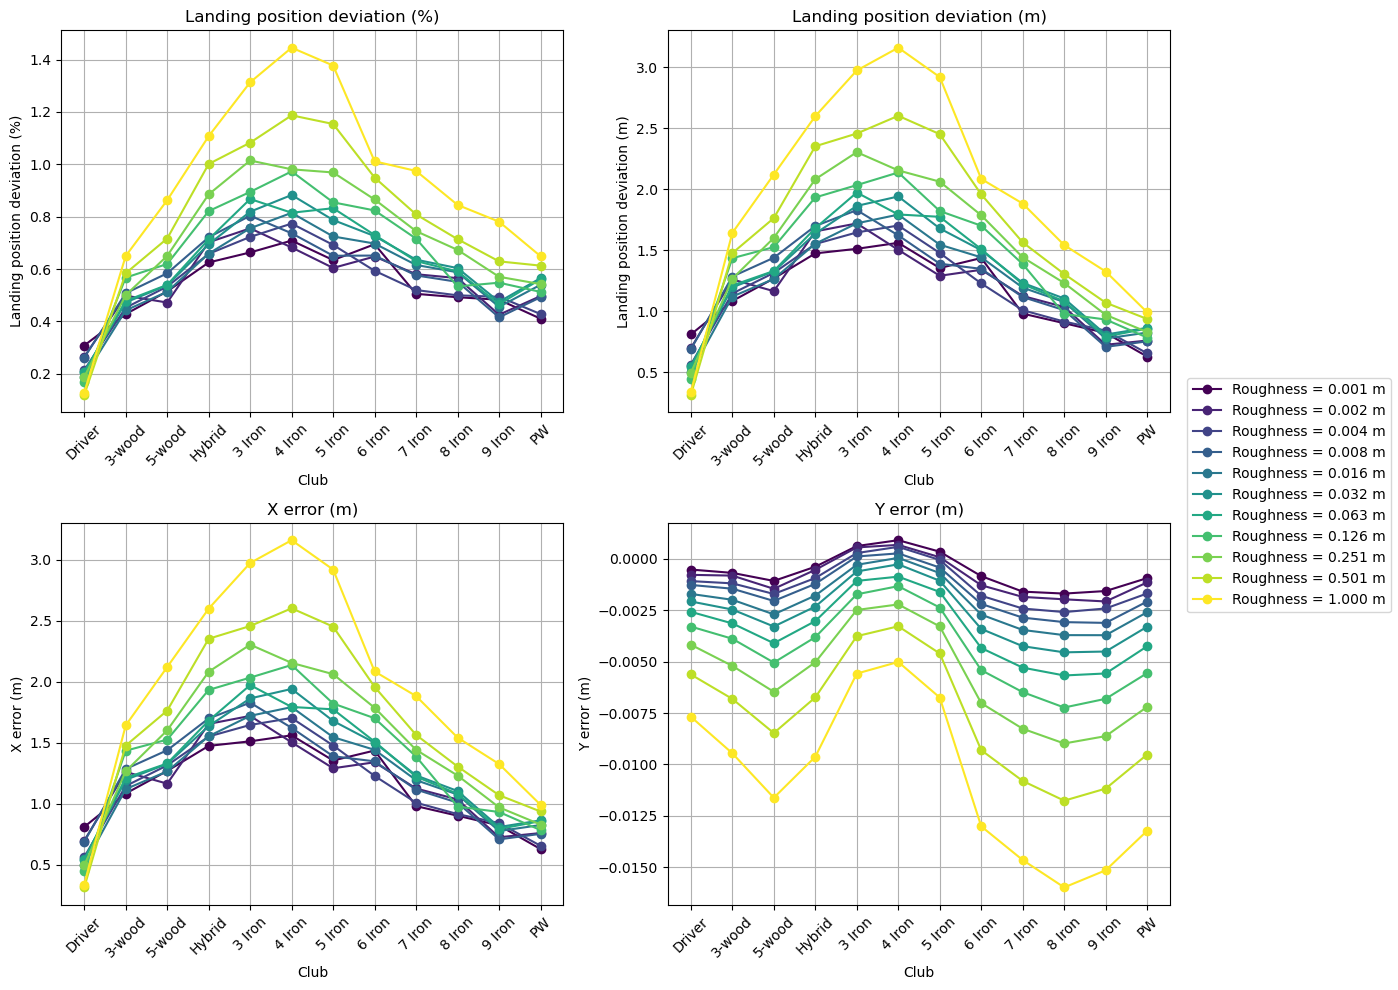

In [32]:
plot_club_vs_parameter(df_pga, "z0")

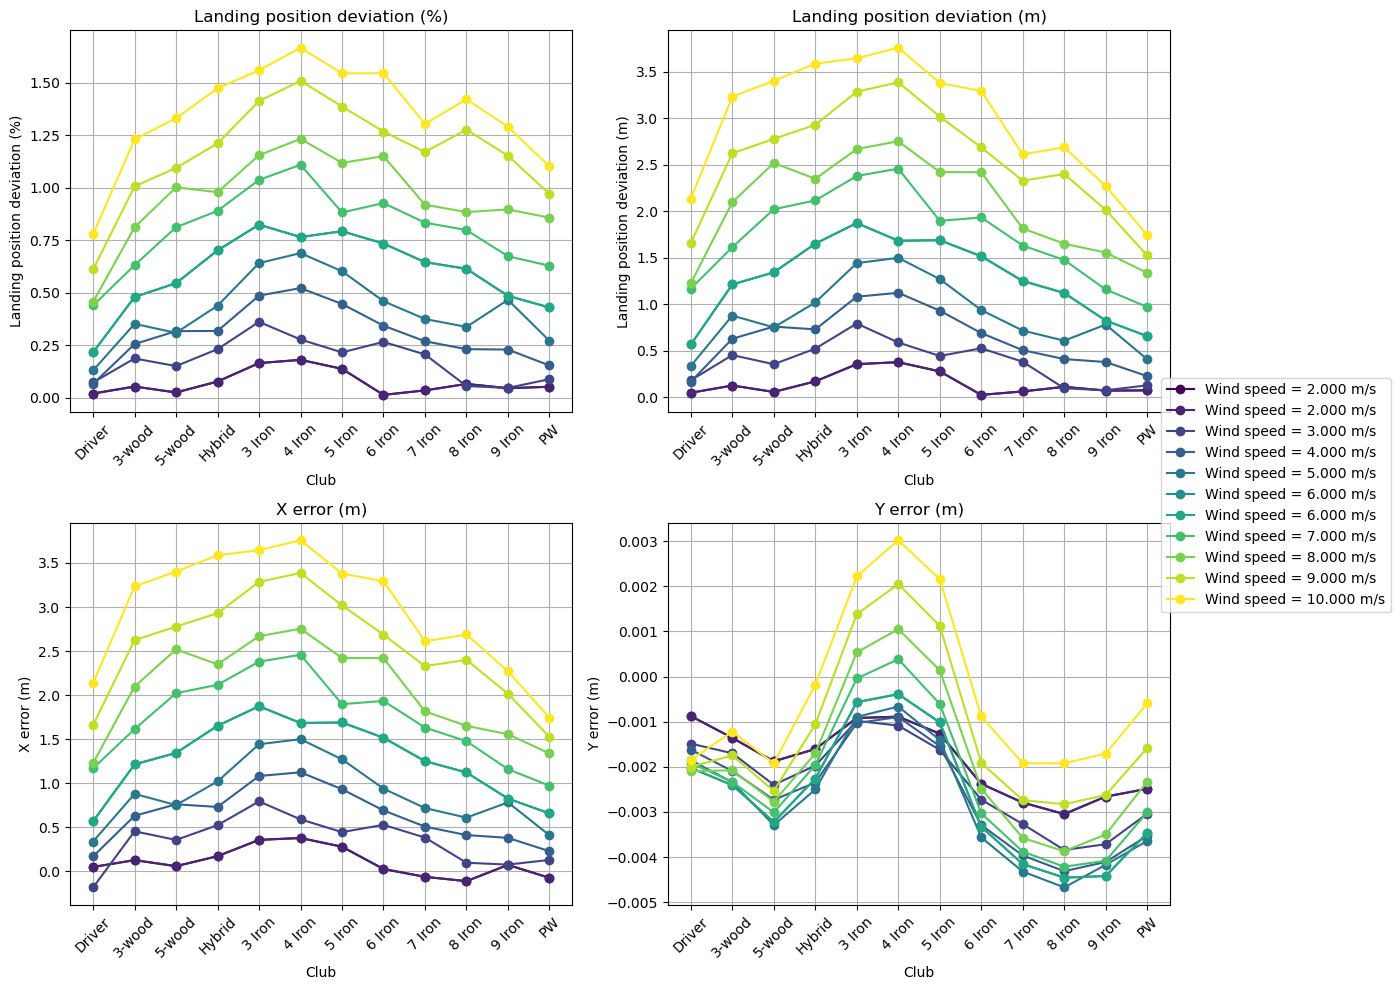

In [33]:
plot_club_vs_parameter(df_pga, "U_ref")

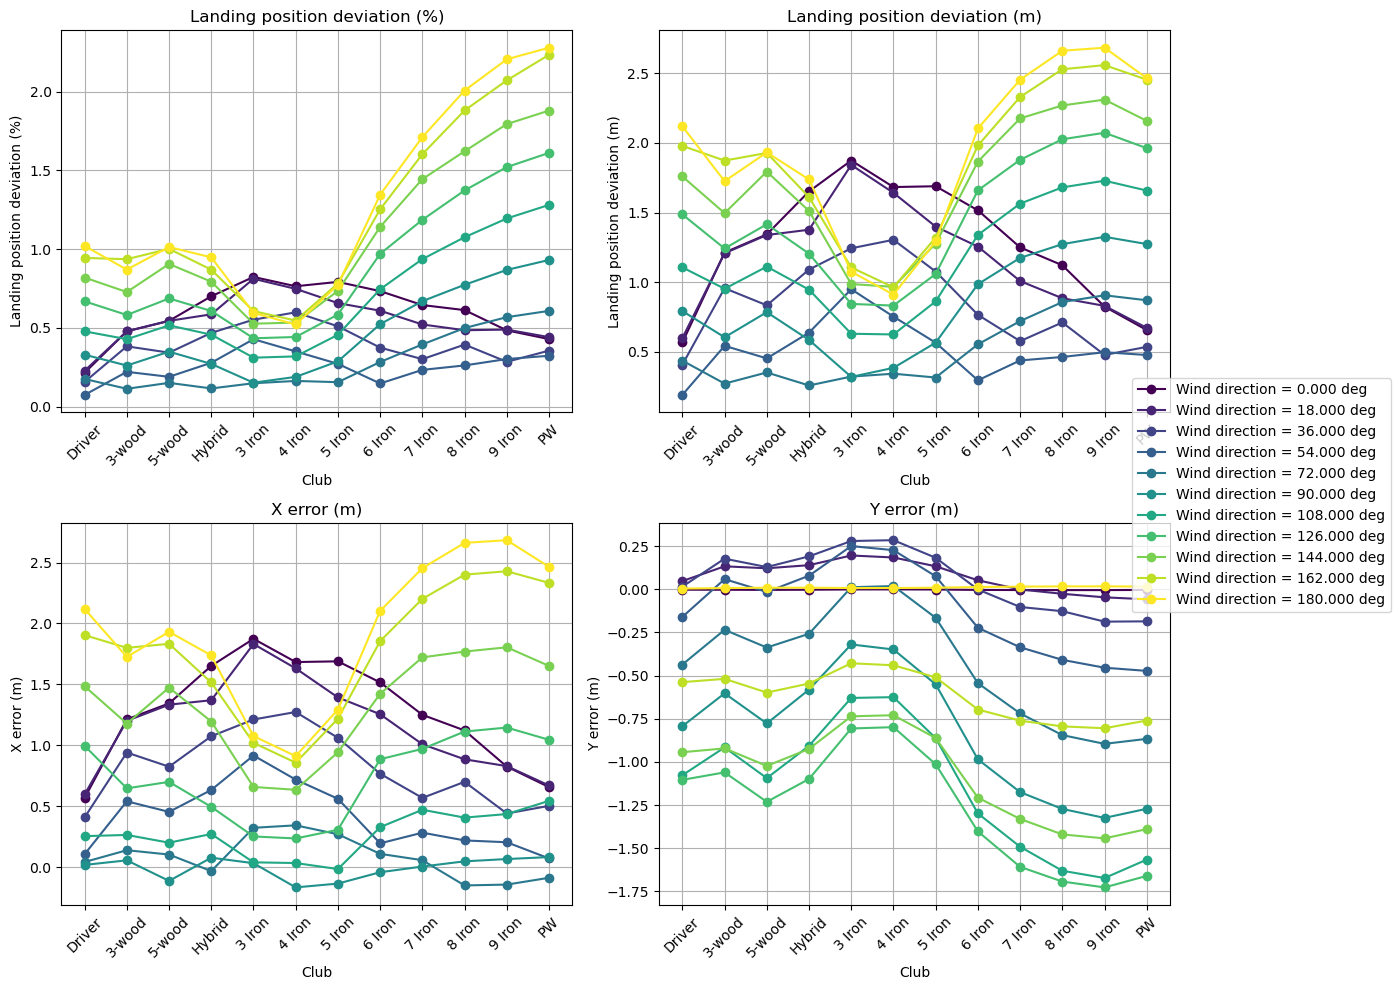

In [34]:
plot_club_vs_parameter(df_pga, "direction")